# **Day 63: CNN Architectures and Transfer Learning**
*Module 10 - Deep Learning Foundations*

From LeNet (1998) to ResNet (2016) to EfficientNet and ConvNeXt, a few architectural ideas made CNNs deeper, more accurate and more efficient. And **transfer learning** (reusing a network trained on a large dataset) is the reason deep learning works even when we have only a few hundred labelled images, which is typical in remote sensing.

> Famous CNN architectures (VGG, ResNet and others) introduced ideas such as skip connections that make deep networks trainable. Transfer learning reuses a network trained on a large data set and adapts it to a small new task.
>
> *Example:* A network trained on millions of satellite images can be fine-tuned to classify mining sites with only a few hundred labelled examples.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, copy, time
import torchvision
from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import gaussian_filter
torch.manual_seed(63); rng = np.random.default_rng(63)
print("torchvision", torchvision.__version__)

torchvision 0.29.1+cpu


## **1. Architecture Milestones**

| Year | Model | Key idea | Depth | ImageNet top-1 |
|---|---|---|---|---|
| 1998 | LeNet-5 | conv + pool for digits | 5 | - |
| 2012 | AlexNet | ReLU, dropout, GPUs, data augmentation | 8 | ~57% |
| 2014 | VGG-16 | stacks of 3x3 convs only | 16 | ~72% |
| 2014 | Inception (GoogLeNet) | parallel multi-scale branches, 1x1 bottlenecks | 22 | ~69% |
| 2015 | **ResNet** | **residual connections** -> 100+ layers | 18-152 | ~76-78% |
| 2017 | DenseNet | each layer gets all previous feature maps | 121+ | ~75% |
| 2017-19 | MobileNet / EfficientNet | depthwise-separable convs; compound scaling | - | ~75-84% |
| 2022 | ConvNeXt | CNN modernised with transformer-era design choices | - | ~82-87% |

## **2. ResNet From Scratch**
A residual block learns a correction $F(x)$ and adds it to its input: $y = \text{ReLU}(x + F(x))$. If a layer is not useful it can learn $F\approx 0$ (identity), so adding layers never hurts optimisation, and gradients flow through the identity shortcut.

In [2]:
class BasicBlock(nn.Module):
    def __init__(self, c_in, c_out, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, stride, 1, bias=False); self.bn1 = nn.BatchNorm2d(c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, 1, 1, bias=False); self.bn2 = nn.BatchNorm2d(c_out)
        self.shortcut = nn.Identity() if stride == 1 and c_in == c_out else nn.Sequential(nn.Conv2d(c_in, c_out, 1, stride, bias=False), nn.BatchNorm2d(c_out))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))                      # the residual connection

class MiniResNet(nn.Module):
    def __init__(self, in_ch=4, n_classes=6, widths=(32, 64, 128)):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(in_ch, widths[0], 3, 1, 1, bias=False), nn.BatchNorm2d(widths[0]), nn.ReLU())
        layers, c = [], widths[0]
        for i, w in enumerate(widths):
            layers += [BasicBlock(c, w, stride=1 if i == 0 else 2), BasicBlock(w, w)]; c = w
        self.layers = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(c, n_classes))
    def forward(self, x):
        return self.head(self.layers(self.stem(x)))
    def features(self, x):
        return self.head[:2](self.layers(self.stem(x)))

net = MiniResNet()
print(f"MiniResNet: {sum(p.numel() for p in net.parameters()):,} parameters | output {tuple(net(torch.randn(2, 4, 32, 32)).shape)}")

MiniResNet: 696,390 parameters | output (2, 6)


## **3. torchvision Models and Multispectral Input**
ImageNet models expect 3-channel RGB. For satellite data with more bands, **replace the first convolution**. A common trick when pretrained weights exist: initialise the extra channels with the mean of the RGB filters (so pretrained knowledge is kept).

In [3]:
resnet18 = torchvision.models.resnet18(weights=None)               # weights="IMAGENET1K_V1" downloads pretrained weights (internet needed)
print("original first layer:", resnet18.conv1)

def adapt_first_conv(model, n_bands):
    old = model.conv1
    new = nn.Conv2d(n_bands, old.out_channels, old.kernel_size, old.stride, old.padding, bias=False)
    with torch.no_grad():
        new.weight[:, :3] = old.weight                                       # keep RGB filters
        new.weight[:, 3:] = old.weight.mean(1, keepdim=True).repeat(1, n_bands - 3, 1, 1)   # extra bands: mean of RGB filters
    model.conv1 = new; return model

resnet13 = adapt_first_conv(torchvision.models.resnet18(weights=None), 13)
resnet13.fc = nn.Linear(resnet13.fc.in_features, 10)                        # new classification head (e.g. 10 EuroSAT classes)
print("adapted:", resnet13.conv1, "| head:", resnet13.fc)
print("output for a batch of Sentinel-2 13-band 64x64 patches:", tuple(resnet13(torch.randn(2, 13, 64, 64)).shape))

original first layer: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)


adapted: Conv2d(13, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False) | head: Linear(in_features=512, out_features=10, bias=True)
output for a batch of Sentinel-2 13-band 64x64 patches: (2, 10)


## **4. Transfer Learning: A Controlled Experiment**
To make the idea concrete without downloading anything, we create:
- a **source** task: a large labelled dataset (2400 patches, 8 **texture** classes; spectra are random, so the network must learn spatial patterns);
- a **target** task: a different but related problem (5 classes: 3 textures seen in the source task and 2 new ones) with **only 3 labelled patches per class**, the realistic situation in a new study area.

We compare training from scratch vs reusing the source network.

In [4]:
def _n(t): return (t - t.mean()) / (t.std() + 1e-9)
def texture(kind, size, r):
    yy, xx = np.mgrid[0:size, 0:size]
    if kind == "smooth": return _n(gaussian_filter(r.normal(size=(size, size)), 6))
    if kind == "rough": return _n(gaussian_filter(r.normal(size=(size, size)), 0.8))
    if kind == "stripes":
        a, per = r.uniform(0, np.pi), r.uniform(5, 10); return _n(np.sin(2 * np.pi * (xx * np.cos(a) + yy * np.sin(a)) / per))
    if kind == "blobs": return _n(gaussian_filter(r.normal(size=(size, size)), 3))
    if kind == "grid":
        b = r.integers(4, 8); return _n((((xx // b) % 2) ^ ((yy // b) % 2)).astype(float))
    if kind == "spots":
        t = np.zeros((size, size)); idx = r.integers(0, size, (12, 2)); t[idx[:, 0], idx[:, 1]] = 6; return _n(gaussian_filter(t, 1.2))
    if kind == "rings":
        cx, cy = r.uniform(8, 24, 2); return _n(np.sin(np.hypot(xx - cx, yy - cy) / 1.5))
    if kind == "gradient":
        a = r.uniform(0, 2 * np.pi); return _n((xx - 16) * np.cos(a) + (yy - 16) * np.sin(a))
    if kind == "fine_checker": return _n((((xx // 2) % 2) ^ ((yy // 2) % 2)).astype(float))
    if kind == "sparse_lines":
        a, per = r.uniform(0, np.pi), r.uniform(10, 16); return _n((np.sin(2 * np.pi * (xx * np.cos(a) + yy * np.sin(a)) / per) > 0.9).astype(float))

def make_task(kinds, n_per_class, size=32, seed=0, noise=0.03):
    r = np.random.default_rng(seed); X, y = [], []
    for k, kind in enumerate(kinds):
        for _ in range(n_per_class):
            s = r.uniform(0.05, 0.35, 4)                                              # random spectrum: the class is defined by texture only
            X.append((s[:, None, None] * (1 + r.uniform(0.15, 0.35) * texture(kind, size, r)[None]) + r.normal(0, noise, (4, size, size))).astype(np.float32)); y.append(k)
    return np.stack(X), np.array(y)

source_kinds = ["smooth", "rough", "stripes", "grid", "blobs", "spots", "rings", "gradient"]
target_kinds = ["stripes", "blobs", "rough", "fine_checker", "sparse_lines"]          # 3 familiar + 2 new textures
Xs, ys = make_task(source_kinds, 300, seed=1)
Xt_tr, yt_tr = make_task(target_kinds, 3, seed=2); Xt_te, yt_te = make_task(target_kinds, 200, seed=3)
nrm = lambda a: torch.tensor((a - a.mean((2, 3), keepdims=True)) / (a.std((2, 3), keepdims=True) + 1e-6))   # per-patch, per-band standardisation
print("source:", Xs.shape, "| target train:", Xt_tr.shape, "| target test:", Xt_te.shape)

source: (2400, 4, 32, 32) | target train: (15, 4, 32, 32) | target test: (1000, 4, 32, 32)


In [5]:
def train(model, X, y, epochs, lr=1e-3, params=None, bs=32, seed=0):
    torch.manual_seed(seed); rr = np.random.default_rng(seed)
    dl = DataLoader(TensorDataset(nrm(X), torch.tensor(y)), batch_size=bs, shuffle=True)
    opt = torch.optim.AdamW(params if params is not None else model.parameters(), lr=lr, weight_decay=1e-4)
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            xb = torch.rot90(xb, int(rr.integers(4)), (2, 3))                          # rotation augmentation (Day 64)
            opt.zero_grad(); F.cross_entropy(model(xb), yb).backward(); opt.step()
    return model

def acc(model, X, y):
    model.eval()
    with torch.no_grad(): return (model(nrm(X)).argmax(1).numpy() == y).mean()

t0 = time.perf_counter()
source_net = train(MiniResNet(n_classes=8), Xs, ys, epochs=8)
Xs_val, ys_val = make_task(source_kinds, 50, seed=9)
print(f"source network trained in {time.perf_counter() - t0:.0f}s; source validation accuracy {acc(source_net, Xs_val, ys_val):.3f}")

source network trained in 214s; source validation accuracy 0.998


### Three strategies on the small target dataset

| Strategy | What is trained | When to use |
|---|---|---|
| From scratch | everything, random init | lots of target data |
| **Feature extraction** (linear probe) | only a new head; backbone frozen | very little data; similar domains |
| **Fine-tuning** | everything, starting from pretrained weights, small LR (lower for early layers) | moderate data; or domain differs |

In [6]:
results = {}
scratch = train(MiniResNet(n_classes=5), Xt_tr, yt_tr, epochs=150)
results["from scratch"] = acc(scratch, Xt_te, yt_te)

# feature extraction: freeze the backbone, train only a new head
fe = copy.deepcopy(source_net); fe.head[2] = nn.Linear(128, 5)
for p in fe.parameters(): p.requires_grad = False
for p in fe.head.parameters(): p.requires_grad = True
fe = train(fe, Xt_tr, yt_tr, epochs=150, lr=1e-2, params=fe.head.parameters())
results["feature extraction (frozen backbone)"] = acc(fe, Xt_te, yt_te)

# fine-tuning with discriminative learning rates: smaller LR for earlier layers
ft = copy.deepcopy(source_net); ft.head[2] = nn.Linear(128, 5)
groups = [{"params": ft.stem.parameters(), "lr": 1e-4}, {"params": ft.layers.parameters(), "lr": 3e-4}, {"params": ft.head.parameters(), "lr": 3e-3}]
ft = train(ft, Xt_tr, yt_tr, epochs=100, params=groups)
results["fine-tuning (layer-wise LRs)"] = acc(ft, Xt_te, yt_te)

from sklearn.ensemble import RandomForestClassifier
f_ = lambda X: np.c_[X.mean((2, 3)), X.std((2, 3))]
results["Random Forest on band stats"] = RandomForestClassifier(300, random_state=0).fit(f_(Xt_tr), yt_tr).score(f_(Xt_te), yt_te)
pd.Series(results, name="target test accuracy (3 labels per class)").round(3)

from scratch                            0.923
feature extraction (frozen backbone)    1.000
fine-tuning (layer-wise LRs)            0.996
Random Forest on band stats             0.205
Name: target test accuracy (3 labels per class), dtype: float64

The pretrained backbone already contains texture detectors learned on the source task, so a handful of labels is enough, even for the two textures it never saw. This is why ImageNet- or satellite-pretrained models dominate small-sample remote sensing studies.

### How many target labels are needed?

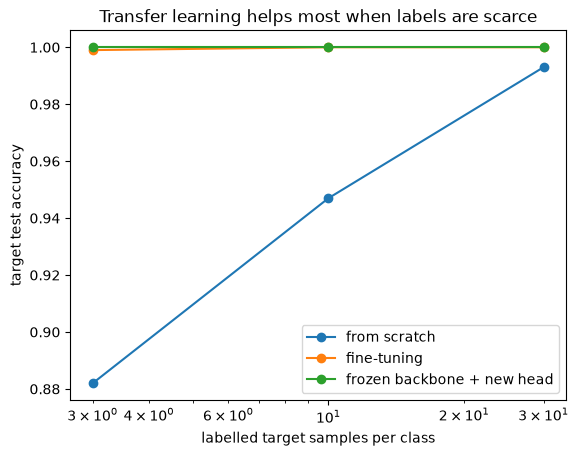

    from scratch  fine-tuning  frozen backbone + new head
3          0.882        0.999                         1.0
10         0.947        1.000                         1.0
30         0.993        1.000                         1.0


In [7]:
curve = {"from scratch": [], "fine-tuning": [], "frozen backbone + new head": []}
ns = [3, 10, 30]
for n in ns:
    Xn, yn = make_task(target_kinds, n, seed=10 + n)
    curve["from scratch"].append(acc(train(MiniResNet(n_classes=5), Xn, yn, epochs=max(30, 450 // n)), Xt_te, yt_te))
    f2 = copy.deepcopy(source_net); f2.head[2] = nn.Linear(128, 5)
    curve["fine-tuning"].append(acc(train(f2, Xn, yn, epochs=max(20, 300 // n), lr=3e-4), Xt_te, yt_te))
    f3 = copy.deepcopy(source_net); f3.head[2] = nn.Linear(128, 5)
    curve["frozen backbone + new head"].append(acc(train(f3, Xn, yn, epochs=max(30, 450 // n), lr=1e-2, params=f3.head.parameters()), Xt_te, yt_te))
for k, v in curve.items(): plt.plot(ns, v, "o-", label=k)
plt.xscale("log"); plt.xlabel("labelled target samples per class"); plt.ylabel("target test accuracy"); plt.legend(); plt.title("Transfer learning helps most when labels are scarce"); plt.show()
print(pd.DataFrame(curve, index=ns).round(3))

# **Part 2: Going Deeper - Pretrained Weights for Remote Sensing**

**Domain gap**: ImageNet photos are RGB, oblique, object-centred; satellite images are multispectral, nadir, with different statistics. ImageNet weights still help (low-level filters transfer), but **remote-sensing-pretrained** weights usually help more:

| Source | Pretraining data | Access |
|---|---|---|
| TorchGeo | Sentinel-2 (SSL4EO-S12), Landsat, NAIP, ... | `torchgeo.models.ResNet18_Weights.SENTINEL2_ALL_MOCO` |
| SSL4EO-S12 (Wang et al., 2023) | 3M Sentinel-1/2 patches, self-supervised | TorchGeo / GitHub |
| Prithvi (NASA-IBM) | HLS (Landsat + Sentinel-2) time series, masked autoencoder ViT | Hugging Face |
| SatlasPretrain, Clay, DOFA | multi-sensor foundation models | GitHub / Hugging Face |

```python
# Example (needs internet + `pip install torchgeo`):
from torchgeo.models import ResNet18_Weights, resnet18
model = resnet18(weights=ResNet18_Weights.SENTINEL2_ALL_MOCO)    # 13-band Sentinel-2 input, self-supervised MoCo weights
model.fc = nn.Linear(512, n_classes)
```
Important: use the **same normalisation** as during pretraining, and match the band order.

### Practical fine-tuning recipe
1. Replace the head; train only the head for a few epochs (warm-up).
2. Unfreeze everything; fine-tune with a small LR (1e-4 to 3e-4, lower for early layers), cosine schedule, augmentation (Day 64), early stopping.
3. With very few labels, prefer linear probing or freezing early blocks.

## **Practice Problems**
1. Freeze only the stem and the first two residual blocks of the source network and fine-tune the rest. Compare with full fine-tuning.
2. Train `MiniResNet` with and without the residual connections (replace `out + self.shortcut(x)` by `out`) on the source task for 6 epochs. Compare training loss.
3. Use the frozen source network's 128-D features (`source_net.features(x)`) with a logistic regression on the 3-label target data.
4. *(Advanced)* Adapt torchvision's `resnet18` to 4 bands with `adapt_first_conv` and train it on the source task for 3 epochs on 32x32 inputs. Why might we remove the initial max-pool for small patches?

partial freezing: 0.998 | full fine-tuning: 0.996


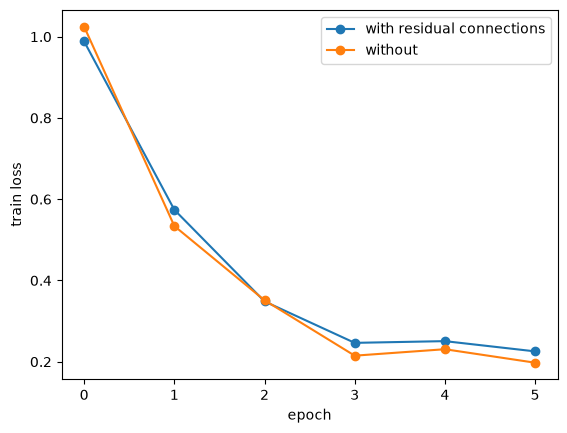

logistic regression on frozen features: 1.0


torchvision ResNet-18 (4 bands): source validation accuracy 0.880 after 3 epochs (106s)


In [8]:
# Solution 1
pf = copy.deepcopy(source_net); pf.head[2] = nn.Linear(128, 5)
for p in list(pf.stem.parameters()) + list(pf.layers[:2].parameters()): p.requires_grad = False
pf = train(pf, Xt_tr, yt_tr, epochs=100, lr=5e-4, params=[p for p in pf.parameters() if p.requires_grad])
print(f"partial freezing: {acc(pf, Xt_te, yt_te):.3f} | full fine-tuning: {results['fine-tuning (layer-wise LRs)']:.3f}")
# Solution 2
class PlainBlock(BasicBlock):
    def forward(self, x):
        return F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))))
def loss_curve(block_cls):
    torch.manual_seed(0); m = MiniResNet(n_classes=8);
    for i, layer in enumerate(m.layers):
        m.layers[i].__class__ = block_cls
    dl = DataLoader(TensorDataset(nrm(Xs), torch.tensor(ys)), 64, shuffle=True); o = torch.optim.SGD(m.parameters(), 0.05, momentum=0.9); out = []
    for ep in range(6):
        m.train(); tot = 0
        for xb, yb in dl: o.zero_grad(); l_ = F.cross_entropy(m(xb), yb); l_.backward(); o.step(); tot += l_.item() * len(yb)
        out.append(tot / len(ys))
    return out
plt.plot(loss_curve(BasicBlock), "o-", label="with residual connections"); plt.plot(loss_curve(PlainBlock), "o-", label="without"); plt.legend(); plt.xlabel("epoch"); plt.ylabel("train loss"); plt.show()
# Solution 3
from sklearn.linear_model import LogisticRegression
source_net.eval()
with torch.no_grad(): F_tr, F_te = source_net.features(nrm(Xt_tr)).numpy(), source_net.features(nrm(Xt_te)).numpy()
print("logistic regression on frozen features:", round(LogisticRegression(max_iter=3000).fit(F_tr, yt_tr).score(F_te, yt_te), 3))
# Solution 4
tv = adapt_first_conv(torchvision.models.resnet18(weights=None), 4); tv.fc = nn.Linear(512, 8)
tv.maxpool = nn.Identity()                                            # 32x32 inputs: avoid shrinking too early (stride-2 conv + max-pool = 4x downsampling)
t0 = time.perf_counter(); train(tv, Xs[::2], ys[::2], epochs=3, lr=1e-3)
print(f"torchvision ResNet-18 (4 bands): source validation accuracy {acc(tv, Xs_val, ys_val):.3f} after 3 epochs ({time.perf_counter() - t0:.0f}s)")

## **Key References**
- Simonyan, K., & Zisserman, A. (2015). Very deep convolutional networks for large-scale image recognition. *ICLR 2015*.
- He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *CVPR 2016*.
- Tan, M., & Le, Q. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. *ICML 2019*.
- Yosinski, J., Clune, J., Bengio, Y., & Lipson, H. (2014). How transferable are features in deep neural networks? *NeurIPS 27*.
- Wang, Y. et al. (2023). SSL4EO-S12: A large-scale multimodal, multitemporal dataset for self-supervised learning in Earth observation. *IEEE Geoscience and Remote Sensing Magazine*, 11(3), 98-106.
- Neumann, M., Pinto, A. S., Zhai, X., & Houlsby, N. (2019). In-domain representation learning for remote sensing. arXiv:1911.06721.